# Convective penetration rays analysis

Works with jupyterlab3 on ppmstar.org

In [1]:
%pylab ipympl

Populating the interactive namespace from numpy and matplotlib


In [2]:
from ppmpy import ppm
import os

In [3]:
# set cycling combination of color-blind labels, glyphs, styles
lll= 2*['-', '--', ':', '-.']
markers = ['X','h','<','>','s','^','d','X','p']
random.shuffle(lll)
CB_color_cycle = ['#4daf4a', '#a65628', '#984ea3',
                  '#ff7f00', '#f781bf', '#377eb8',
                  '#999999', '#e41a1c', '#dede00']
rc('axes', prop_cycle=(cycler('color', CB_color_cycle[0:8]) + cycler('marker',markers[0:8])+cycler('linestyle',lll)))
rc('axes', prop_cycle=(cycler('color', CB_color_cycle[0:8]) +cycler('linestyle',lll)))

# named tuple for using rprofs and momsdata
# moms data are almost always used alongside rprof data and therefore it is recommended 
# to create a convenient dictionary that will hold the rprof and moms instance 
import collections
hydro = collections.namedtuple('hydro', ['moms','rprof'])

# turn off matplotlib messages
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)

In [4]:
# the list of variables that are stored within the momsdata cube.
var_list = ['vort','ur','ut','4','5','6','7','T9','P','10']

In [5]:
dump_select = 500 
data_dir = '/home/user/user/frontera_scratch3_pwoodwar/'
run_dir = 'X38-Texascale-1xL-mc12400-rot-77kms-at-1100Mm'

In [6]:
moms_dir = os.path.join(data_dir,run_dir,'moms/myavsbq')
rprof_dir = os.path.join(data_dir,run_dir,'prfs')
# load moms instance
dump = dump_select
moms = ppm.MomsDataSet(moms_dir,init_dump_read=dump,dumps_in_mem=1,var_list=var_list,rprofset=ppm.RprofSet(rprof_dir))
run = hydro(moms,  ppm.RprofSet(rprof_dir))

1418 rprof files found in '/home/user/user/frontera_scratch3_pwoodwar/X38-Texascale-1xL-mc12400-rot-77kms-at-1100Mm/prfs/.
Dump numbers range from 0 to 1417.
5 .aaa files found in '/home/user/user/frontera_scratch3_pwoodwar/X38-Texascale-1xL-mc12400-rot-77kms-at-1100Mm/moms/myavsbq/.
Dump numbers range from 300 to 700.
1418 rprof files found in '/home/user/user/frontera_scratch3_pwoodwar/X38-Texascale-1xL-mc12400-rot-77kms-at-1100Mm/prfs/.
Dump numbers range from 0 to 1417.


In [7]:
T = run.moms.get('T9')
P = run.moms.get('P')
x,y,z = run.moms.get_cgrid()

In [8]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [9]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree

def spherical_to_cartesian_y(r, theta, phi):
    x = r * np.cos(theta) * np.cos(phi)
    y = r * np.sin(theta)                # y is up (North)
    z = r * np.cos(theta) * np.sin(phi)
    return x, y, z

def generate_structured_paths(theta_angles, num_phi, max_r, num_points):
    paths = []
    r_values = np.linspace(0, max_r, num_points)
    for theta in theta_angles:
        phi_angles = np.linspace(0, 2*np.pi, num_phi)
        for phi in phi_angles:
            x, y, z = spherical_to_cartesian_y(r_values, theta * np.ones_like(r_values), phi * np.ones_like(r_values))
            paths.append(np.column_stack((x, y, z)))
    return np.vstack(paths), r_values

def cdiff(arr):
    # 2nd order centered difference
    return (arr[2:] - arr[:-2]) / 2

def calculate_nabla_T(x, y, z, P, T, theta_angles, num_phi=60, num_points=250):
    # Flatten the coordinate arrays and create a KD-tree
    coords = np.column_stack((x.ravel(), y.ravel(), z.ravel()))
    tree = cKDTree(coords)
    
    # Get the maximum radius
    max_r = 1100
    
    # theta_angles deg to rad
    theta_angles = theta_angles*np.pi/180
    
    # Generate structured paths
    paths, r_values = generate_structured_paths(theta_angles, num_phi, max_r, num_points)
    
    # Find nearest neighbors for all points in all paths at once
    _, indices = tree.query(paths, k=1)
    
    # Reshape indices to match the original path structure
    indices = indices.reshape(len(theta_angles), num_phi, num_points)
    
    nabla_T_results = []
    
    for i, theta in enumerate(theta_angles):
        nabla_T_phi = []
        for j in range(num_phi):
            path_indices = indices[i, j]
            
            # Get P and T values along the path
            P_path = P.ravel()[path_indices]
            T_path = T.ravel()[path_indices]
            
            # Calculate nabla_T
            log_T_diff = cdiff(np.log(T_path))
            log_P_diff = cdiff(np.log(P_path))
            nabla_T = log_T_diff / (log_P_diff + 1e-100)
            
            nabla_T_phi.append(nabla_T)
        
        # Average over phi angles
        nabla_T_avg = np.mean(nabla_T_phi, axis=0)
        nabla_T_results.append(nabla_T_avg)
    
    return nabla_T_results, r_values[1:-1]

In [10]:
theta_angles = np.array([0, 15, 30, 45, 60, 75, 90])
nabla_T_results, r_values = calculate_nabla_T(x, y, z, P, T, theta_angles)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:59: RuntimeWarning: invalid value encountered in true_divide


In [11]:
matplotlib.rcParams.update({'font.size': 12})

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


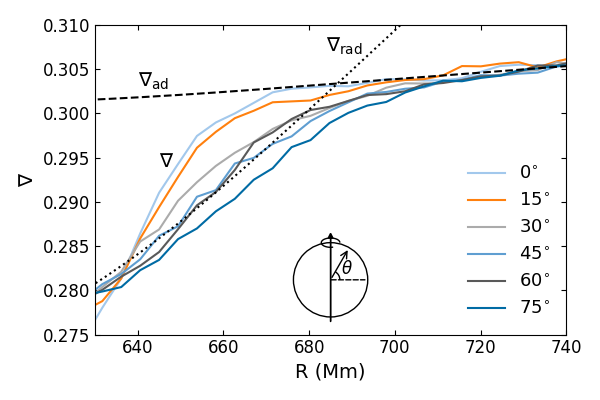

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Arc

plt.close(1)
fig, ax = plt.subplots(figsize=(6, 4))

for i, gradT in enumerate(nabla_T_results):
    if theta_angles[i]<90:
        ax.plot(r_values, gradT, label="{:.0f}".format(theta_angles[i])+r'$^{\circ}$', 
                 ls='-', color=ut.linestylecb(i)[2])

R_rprof = run.rprof.get('R', fname=dump_select, num_type='NDump')
nablaTad = run.rprof.compute_nabla_T_ad(fname=dump_select, num_type='NDump')
nablaTrad = run.rprof.compute_nabla_T_rad(fname=dump_select, num_type='NDump')
ax.plot(R_rprof, nablaTad, '--k')
ax.plot(R_rprof, nablaTrad, ':k')

ax.set_xlim(630, 740)
ax.set_ylim(0.275, 0.31)
ax.legend(frameon=False, fontsize=13)
ax.set_xlabel('R (Mm)', size=14)
ax.set_ylabel(r'$\nabla$', size=14)

# Make tick marks go inward and add them to top and right axes
ax.tick_params(direction='in', top=True, right=True)

# Create an inset axes for the theta angle illustration
axins = inset_axes(ax, width="30%", height="30%", loc='lower center')

# Draw the star (circle) and rotation axis
circle = plt.Circle((0, 0), 0.8, fill=False)
axins.add_artist(circle)
axins.arrow(0, -0.9, 0, 1.8, head_width=0.1, head_length=0.1, fc='k', ec='k')

# Add curved arrow to indicate rotation
rotation_arrow = Arc((0, 0.8), 0.4, 0.2, angle=0, theta1=0, theta2=300, 
                     color='black', linewidth=1.)
axins.add_patch(rotation_arrow)
# axins.annotate('', xy=(0.2, 0.05), xytext=(0.2, -0.05),
#                arrowprops=dict(arrowstyle='->', color='black'))
angle = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=60, 
                     color='black', linewidth=1.)
axins.add_patch(angle)

# Draw the angle theta
theta = np.radians(30)  # Example angle, adjust as needed
axins.annotate('', xy=(0.8*np.sin(theta), 0.8*np.cos(theta)), xytext=(0, 0),
               arrowprops=dict(arrowstyle='->', color='black'))
axins.annotate('', xy=(0.8, 0), xytext=(-0.05, 0),
               arrowprops=dict(arrowstyle='-', color='black', linestyle='dashed'))
axins.text(0.22, 0.13, r'$\theta$', color='black', fontsize=12)

# Remove axes ticks and labels from the inset
axins.set_xticks([])
axins.set_yticks([])

# Set limits for the inset axes and make it square
axins.set_xlim(-1, 1)
axins.set_ylim(-1, 1)
axins.set_aspect('equal', adjustable='box')
for spine in axins.spines.values():
    spine.set_visible(False)
    
    
ax.text(640, 0.303, r'$\nabla_{\rm ad}$', size=14)
ax.text(684, 0.307, r'$\nabla_{\rm rad}$', size=14)
ax.text(645, 0.294, r'$\nabla$', size=14)

plt.tight_layout()
plt.show()